In [65]:
# --- Cell 1: Imports ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# helper to show images
def show(img, title=""):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

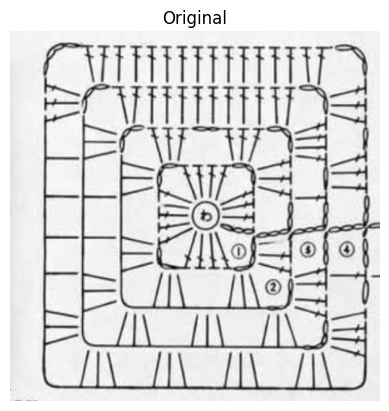

In [66]:
# --- Cell 2: Load image ---
IMG_PATH = "data/raw/easy/2.png"  # change this

img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512))

show(img, "Original")

In [67]:
# --- Cell 3: Find center automatically ---
# use image center (works well for granny squares)

h, w = img.shape
center = (w // 2, h // 2)

print("Center:", center)

Center: (256, 256)


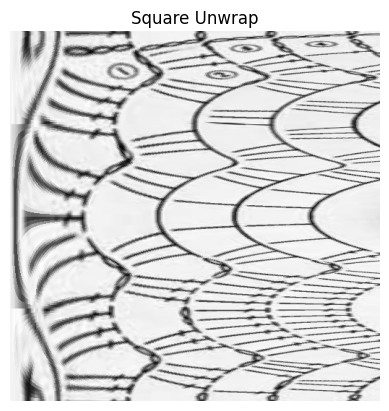

In [68]:
# --- Cell 3: Square-style radial unwrap ---
# custom grid sampling (more structured)

def square_unwrap(img, center, size=512):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    for i in range(size):
        for j in range(size):
            # map square grid → polar
            angle = (i / size) * 2 * np.pi
            radius = (j / size) * min(cx, cy)

            x = int(cx + radius * np.cos(angle))
            y = int(cy + radius * np.sin(angle))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result


# --- Improved square unwrap (layer-based) ---

def square_unwrap_fixed(img, center, size=512):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    max_radius = min(cx, cy)

    for i in range(size):
        for j in range(size):
            
            # map to square coordinates [-1, 1]
            x_norm = (j / size) * 2 - 1
            y_norm = (i / size) * 2 - 1

            # square "radius" (Chebyshev distance)
            r = max(abs(x_norm), abs(y_norm))

            # angle-like parameter along square perimeter
            if abs(x_norm) > abs(y_norm):
                t = y_norm / abs(x_norm)
                if x_norm > 0:
                    angle = t
                else:
                    angle = 2 - t
            else:
                t = x_norm / abs(y_norm) if y_norm != 0 else 0
                if y_norm > 0:
                    angle = 1 - t
                else:
                    angle = 3 + t

            angle = angle / 4  # normalize to [0,1]

            radius = r * max_radius

            theta = angle * 2 * np.pi

            x = int(cx + radius * np.cos(theta))
            y = int(cy + radius * np.sin(theta))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result

square = square_unwrap(img, center)
show(square, "Square Unwrap")

/var/folders/b5/4hk8xrkx3x50b85sdqdmy76w0000gn/T/ipykernel_50659/590200213.py:75: RuntimeWarning: divide by zero encountered in divide
  r_max = 0.5 * np.minimum(w / cos_t, h / sin_t)


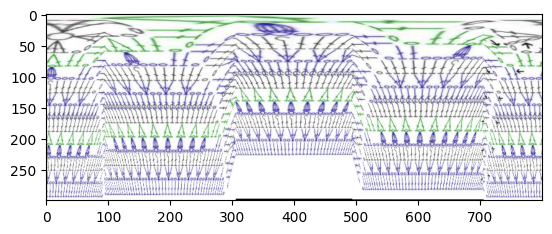

In [91]:
import cv2
import numpy as np

import cv2
import numpy as np

def find_center_distance_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Calculate distance to nearest 0-pixel
    dist_trans = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    
    # The peak of the distance transform is the center
    _, max_val, _, max_loc = cv2.minMaxLoc(dist_trans)
    
    return max_loc # Returns (x, y)

def find_center_contour(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edged = cv2.Canny(gray, 50, 150)
    
    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Find the largest contour (presumably your square)
        largest_cnt = max(contours, key=cv2.contourArea)
        
        # Get the bounding rect (or use minAreaRect for rotated squares)
        x, y, w, h = cv2.boundingRect(largest_cnt)
        
        cX = x + (w // 2)
        cY = y + (h // 2)
        return (cX, cY)
    return None

def find_center_moments(image):
    # Convert to grayscale and blur to reduce noise
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Threshold to get a binary image
    _, thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)
    
    # Calculate moments
    M = cv2.moments(thresh)
    
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        return (cX, cY)
    return None

def unwrap_square(image, output_size=(300, 800)):
    h, w = image.shape[:2]
    center_x, center_y = find_center_moments(image)
    
    # Create the destination grid
    out_h, out_w = output_size
    unwrapped = np.zeros((out_h, out_w, 3), dtype=np.uint8)
    
    # Map coordinates
    # theta goes from 0 to 2*pi
    # r goes from 0 to the "edge" of the square
    theta = np.linspace(0, 2 * np.pi, out_w)
    r_norm = np.linspace(0, 1, out_h)
    
    # Vectorized meshgrid for speed
    T, R = np.meshgrid(theta, r_norm)
    
    # The "Magic": Calculate the distance to the edge of a square at angle T
    # This prevents the stretching seen in linear polar transforms
    cos_t = np.abs(np.cos(T))
    sin_t = np.abs(np.sin(T))
    r_max = 0.5 * np.minimum(w / cos_t, h / sin_t)
    
    # Calculate actual source pixel positions
    actual_r = R * r_max
    src_x = center_x + actual_r * np.cos(T)
    src_y = center_y + actual_r * np.sin(T)
    
    # Use remap to interpolate the pixels
    unwrapped = cv2.remap(image, src_x.astype(np.float32), src_y.astype(np.float32), 
                          interpolation=cv2.INTER_LINEAR)
    
    return unwrapped

# Usage
img = cv2.imread('data/raw/img/0.png')
result = unwrap_square(img)
plt.imshow(result)

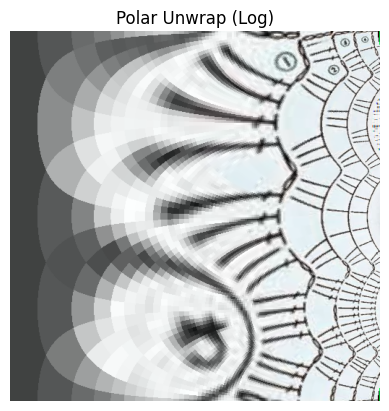

In [70]:
# --- Cell 4: Circular (polar) unwrap ---
# unwrap spiral into rectangle

max_radius = min(center[0], center[1])

polar = cv2.warpPolar(
    img,
    (512, 512),
    center,
    max_radius,
    cv2.WARP_POLAR_LOG
)

show(polar, "Polar Unwrap (Log)")

In [71]:
# --- Cell 5: Square-style radial unwrap ---
# custom grid sampling (more structured)

def square_unwrap(img, center, size=512):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    for i in range(size):
        for j in range(size):
            # map square grid → polar
            angle = (i / size) * 2 * np.pi
            radius = (j / size) * min(cx, cy)

            x = int(cx + radius * np.cos(angle))
            y = int(cy + radius * np.sin(angle))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result


# --- Squoval unwrap (L-p norm based) ---

def square_unwrap_fixed(img, center, size=512, p=50):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    max_radius = min(cx, cy)

    for i in range(size):
        for j in range(size):
            
            # map to square coordinates [-1, 1]
            x_norm = (j / size) * 2 - 1
            y_norm = (i / size) * 2 - 1

            # L-p norm for squoval shape (p=2 circle, p=inf square, p=4 rounded square)
            r = (abs(x_norm)**p + abs(y_norm)**p)**(1/p)
            theta = np.arctan2(y_norm, x_norm)

            radius = r * max_radius

            x = int(cx + radius * np.cos(theta))
            y = int(cy + radius * np.sin(theta))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result

square = square_unwrap_fixed(img, center)
show(square, "Squoval Unwrap")

ValueError: too many values to unpack (expected 2)

In [ ]:
# --- Cell 6: Save outputs ---
os.makedirs("outputs", exist_ok=True)

cv2.imwrite("outputs/polar.png", polar)
cv2.imwrite("outputs/square.png", square)
cv2.imwrite("outputs/square_filtered.png", filtered_square)

print("Saved to outputs/")

Saved to outputs/
